# TBD Phase 2: Performance & Computing Models

## Introduction
In this lab, you will compare the performance and computing models of four popular data processing engines: **Polars, Pandas, DuckDB, and PySpark**.

You will explore:
- **Performance**: Single-node processing speed, parallel execution, and memory usage.
- **Scalability**: How performance changes with the number of cores (single-node) and executors (cluster).
- **Computing Models**: Out-of-core vs. In-memory processing, and Eager vs. Lazy execution.

### Engine Capabilities
The following table summarizes the key capabilities of the engines we will be testing. Use this as a reference.

| Engine | Query Optimizer | Distributed | Arrow-backed | Out-of-Core | Parallel | APIs | GPU Support |
|---|---|---|---|---|--|---|---|
| **Pandas** | ❌ | ❌ | optional ≥ 2.0 | ❌ | ❌ | DataFrame | ❌ |
| **Polars** | ✅ | ❌ | ✅ | ✅ | ✅ | DataFrame | ✅ (opt) |
| **PySpark** | ✅ | ✅ | Pandas UDF/IO | ✅ | ✅ | SQL, DataFrame | ❌ (no GPU) |
| **DuckDB** | ✅ | ❌ | ✅ | ✅ | ❌ | SQL, Relational API | ❌ |

## Prerequisites
Ensure you have the necessary libraries installed.

In [ ]:
# %pip install polars pandas duckdb pyspark faker deltalake memory_profiler pyarrow

In [1]:
import polars as pl
import pandas as pd
import duckdb
from pyspark.sql import SparkSession
from faker import Faker
import numpy as np
import os
import time
import psutil
from memory_profiler import memory_usage
import matplotlib.pyplot as plt
import copy

In [2]:
# Initialize Spark (Single Node)
spark = SparkSession.builder \
    .appName("BigDataLab2") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 14:22:24 WARN Utils: Your hostname, miklap, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 14:22:24 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 14:22:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Part 1: Data Generation

We will generate a synthetic dataset simulating social media posts with a rich schema.

**Schema**:
- `post_id` (String): Unique identifier.
- `user_id` (Integer): User identifier.
- `timestamp` (DateTime): Time of post.
- `content` (String): Text content.
- `likes` (Integer): Number of likes.
- `views` (Integer): Number of views.
- `category` (String): Post category.
- `tags` (List[String]): Hashtags.
- `location` (String): User location.
- `device` (String): Device used (Mobile, Web, etc.).
- `latency` (Float): Network latency.
- `error_rate` (Float): Error rate during upload.

In [ ]:
def generate_data(num_records=1_000_000, output_path="social_media_data.parquet"):
    fake = Faker()

    print(f"Generating {num_records} records...")

    # Generate data using numpy for speed where possible
    data = {
        "post_id": [fake.uuid4() for _ in range(num_records)],
        "user_id": np.random.randint(1, 100_000, num_records),
        "timestamp": pd.date_range(start="2023-01-01", periods=num_records, freq="s").to_numpy().astype("datetime64[us]"),
        "likes": np.random.randint(0, 10_000, num_records),
        "views": np.random.randint(0, 1_000_000, num_records),
        "category": np.random.choice(["Tech", "Health", "Travel", "Food", "Fashion", "Politics", "Sports"], num_records),
        "tags": [np.random.choice(["#viral", "#new", "#trending", "#hot", "#update"], size=np.random.randint(1, 4)).tolist() for _ in range(num_records)],
        "location": np.random.choice(["USA", "UK", "DE", "PL", "FR", "JP", "BR"], num_records),
        "device": np.random.choice(["Mobile", "Desktop", "Tablet"], num_records),
        "latency": np.random.uniform(10.0, 500.0, num_records),
        "error_rate": np.random.beta(1, 10, num_records),
        "content": [fake.sentence() for _ in range(min(num_records, 1000))] * (num_records // 1000 + 1)
    }

    # Trim to exact size
    data["content"] = data["content"][:num_records]

    df = pd.DataFrame(data)

    print("Writing to Parquet...")
    df.to_parquet(output_path, engine="pyarrow")
    print(f"Data saved to {output_path}")

# Generate 5 million records
generate_data(num_records=5_000_000)

## Part 2: Measuring Performance

### 2.1 Execution Time
Use `%time` or `%timeit` to measure execution time.

In [3]:
# Example: Measuring time for all engines
print("--- Performance Benchmark Example ---")

# Pandas
print("Pandas Load Time:")
%time df_pd = pd.read_parquet("social_media_data.parquet")

# Polars
print("\nPolars Load Time:")
%time df_pl = pl.read_parquet("social_media_data.parquet")

# DuckDB
print("\nDuckDB Query Time:")
%time duckdb.sql("SELECT count(*) FROM 'social_media_data.parquet'").show()

# PySpark
print("\nSpark Load Time:")
%time df_spark = spark.read.parquet("social_media_data.parquet"); df_spark.count()

--- Performance Benchmark Example ---
Pandas Load Time:
CPU times: user 11.3 s, sys: 9.6 s, total: 20.9 s
Wall time: 12.9 s

Polars Load Time:
CPU times: user 2.99 s, sys: 3.18 s, total: 6.17 s
Wall time: 2.16 s

DuckDB Query Time:
┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      5000000 │
└──────────────┘

CPU times: user 7.42 ms, sys: 39.6 ms, total: 47 ms
Wall time: 32 ms

Spark Load Time:


CPU times: user 29.3 ms, sys: 40.8 ms, total: 70 ms
Wall time: 8.3 s


5000000

## Part 3: Student Tasks

### Task 1: Performance & Scalability (Single Node)

**Goal**: Benchmark the engines and test how they scale with available CPU cores.

**Instructions**:
1.  **Define Queries**: Create 3 distinct queries of your own choice. They should cover:
    -   **Query A**: A simple aggregation (e.g., grouping by a categorical column and calculating means).
    -   **Query B**: A window function or more complex transformation.
    -   **Query C**: A join (e.g., self-join or join with a smaller generated table) with filtering.
2.  **Benchmark**: Implement these queries in **Pandas, Polars, DuckDB, and PySpark**.
    -   Measure **Execution Time** using `%time` or `time.time()`.
    -   Measure **Peak Memory** usage using `memory_profiler` (e.g., `memory_usage()`).
3.  **Scalability Test**: 
    -   SELECT **all engines** that support parallel execution on a single node (e.g., Polars, DuckDB).
    -   Run **all 3 queries** with different numbers of threads/cores (e.g., 1, 2, 4, 8).
    -   Plot the speedup for each query and engine.

**Tip**: 
-   Polars: [polars.thread_pool_size](https://docs.pola.rs/api/python/stable/reference/api/polars.thread_pool_size.html) Please also note that *Thread configuration in Polars requires process restart*
-   DuckDB: `PRAGMA threads=n`
-   Spark: `master="local[n]"`

#### T1.1. Queries definition



---

1. Simple aggregation
```sql
-- SELECT device types and its technical information averages
SELECT
    device,
    count(*) as device_count,
    mean(latency) as avg_altency,
    mean(error_rate) as avg_error_rate
FROM
    db_table
GROUP BY
    device
```

---

2. Window functions
```sql
SELECT
    post_id,
    category,
    DATE(timestamp) AS post_date,
    likes,
    views,
    RANK() OVER (
        PARTITION BY category, DATE(timestamp)
        ORDER BY likes DESC
    ) AS daily_like_rank,
    AVG(views) OVER (
        PARTITION BY category
        ORDER BY timestamp
        ROWS BETWEEN 100 PRECEDING AND CURRENT ROW
    ) AS rolling_avg_views
FROM
    db_table;
```

---

3. JOINs
```sql
-- SELECT all post_ids and get previous post_id of the 1st post uploader (user_id)
WITH posts_ranked AS (
    SELECT
        post_id
        , user_id
        , ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY timestamp DESC
        ) AS userpost_history
    FROM
        db_table
)
SELECT
    cur.user_id as user_id
    , cur.post_id as post_id
    , prev.post_id as prevoius_post_id
FROM
    posts_ranked cur
LEFT JOIN
    posts_ranked prev
ON
    cur.user_id = prev.user_id
    AND cur.userpost_history = prev.userpost_history - 1
```


<!-- ```sql
SELECT
    p1.post_id AS current_post,
    p2.post_id AS previous_post,
    p1.user_id,
    p1.likes AS current_likes,
    p2.likes AS previous_likes,
    p1.timestamp
FROM
    db_table p1
JOIN db_table p2
    ON p1.user_id = p2.user_id
    AND p2.timestamp = (
        SELECT MAX(timestamp)
        FROM db_table
        WHERE user_id = p1.user_id
          AND timestamp < p1.timestamp
   )
WHERE
    p1.likes > p2.likes;
``` -->

---

#### T1.2. Benchmarks

In [4]:
# Your Code Here for Task 1
import utils

# TABLE_LOCATION = "/media/mikic202/Nowy1/uczelnia/semestr_9/social_media_data.parquet"
TABLE_LOCATION = "./social_media_data.parquet"

Pandas

Polars

DuckDB

In [5]:
print(" --- Query 1: --- ")
duck_db_tim_q1 = utils.benchmark_duckdb_time(TABLE_LOCATION, utils.AGGREGATION_QUERY)
duck_db_mem_q1 = utils.benchmark_duckdb_memory(TABLE_LOCATION, utils.AGGREGATION_QUERY)

print("\n\n --- Query 2 --- ")
duck_db_tim_q2 = utils.benchmark_duckdb_time(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY)
duck_db_mem_q2 = utils.benchmark_duckdb_memory(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY)

print("\n\n --- Query 3 --- ")
duck_db_tim_q3 = utils.benchmark_duckdb_time(TABLE_LOCATION, utils.JOIN_QUERY)
duck_db_mem_q3 = utils.benchmark_duckdb_memory(TABLE_LOCATION, utils.JOIN_QUERY)

 --- Query 1: --- 
Repeats number: 5
Execution times: [0.113, 0.064, 0.066, 0.062, 0.06]
First time: 0.113s
Mean  time: 0.073s
Best  time: 0.060s
Peak Memory Usage: 3524.578 MiB


 --- Query 2 --- 
Repeats number: 5


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Execution times: [9.586, 9.637, 9.473, 9.518, 9.62]
First time: 9.586s
Mean  time: 9.567s
Best  time: 9.473s


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Peak Memory Usage: 5895.188 MiB


Spark

In [6]:
spark_benchmark_obj = utils.SparkBenchmarkObject(session=spark, df=df_spark)

In [7]:
print(" --- Query 1: --- ")
spark_tim_q1 = utils.benchmark_spark_time(spark_benchmark_obj=spark_benchmark_obj, query=utils.AGGREGATION_QUERY)
spark_mem_q1 = utils.benchmark_spark_memory(spark_benchmark_obj=spark_benchmark_obj, query=utils.AGGREGATION_QUERY)
print("\n\n --- Query 2 --- ")
spark_tim_q2 = utils.benchmark_spark_time(spark_benchmark_obj=spark_benchmark_obj, query=utils.WINDOWFUNCTION_QUERY)
spark_mem_q2 = utils.benchmark_spark_memory(spark_benchmark_obj=spark_benchmark_obj, query=utils.WINDOWFUNCTION_QUERY)

print("\n\n --- Query 3 --- ")
spark_tim_q3 = utils.benchmark_spark_time(spark_benchmark_obj=spark_benchmark_obj, query=utils.JOIN_QUERY)
spark_mem_q3 = utils.benchmark_spark_memory(spark_benchmark_obj=spark_benchmark_obj, query=utils.JOIN_QUERY)

spark.stop()


 --- Query 1: --- 
Repeats number: 5


Execution times: [3.981, 1.741, 1.16, 1.09, 1.028]
First time: 3.981s
Mean  time: 1.800s
Best  time: 1.028s


Peak Memory Usage: 3732.58203125 MiB


 --- Query 2 --- 
Repeats number: 5


Execution times: [70.065, 70.771, 62.803, 72.471, 66.822]
First time: 70.065s
Mean  time: 68.586s
Best  time: 62.803s


Peak Memory Usage: 5234.90625 MiB


 --- Query 3 --- 
Repeats number: 5


Execution times: [58.174, 56.492, 50.724, 50.089, 51.012]
First time: 58.174s
Mean  time: 53.298s
Best  time: 50.089s


Peak Memory Usage: 4612.48828125 MiB


#### T1.3. Scalability

In [8]:
MAX_NUMBER_OF_THREADS = 10

DuckDB

In [9]:

times_per_core_agregation = utils.scalability_duckdb(TABLE_LOCATION, utils.AGGREGATION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for DuckDB for agregation query:")
for cores, t in times_per_core_agregation.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_window = utils.scalability_duckdb(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for DuckDB for window function query:")
for cores, t in times_per_core_window.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_join= utils.scalability_duckdb(TABLE_LOCATION, utils.JOIN_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for DuckDB for join query:")
for cores, t in times_per_core_join.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")


Times per core for DuckDB for agregation query:
Cores:  1, Time: 0.1967 seconds
Cores:  2, Time: 0.1239 seconds
Cores:  4, Time: 0.1092 seconds
Cores:  8, Time: 0.1392 seconds


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Times per core for DuckDB for join query:
Cores:  1, Time: 12.9981 seconds
Cores:  2, Time: 10.7896 seconds
Cores:  4, Time: 11.0972 seconds
Cores:  8, Time: 9.9428 seconds


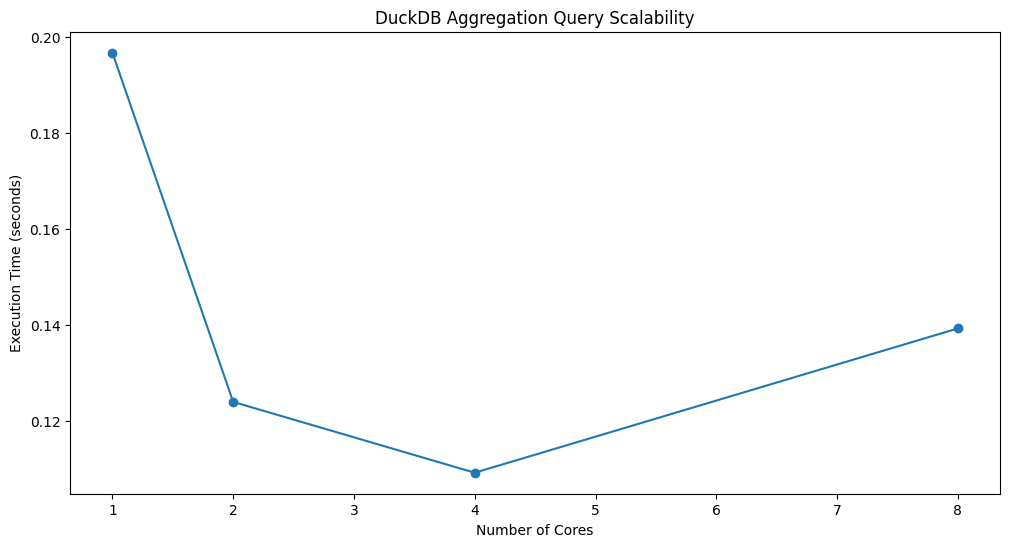

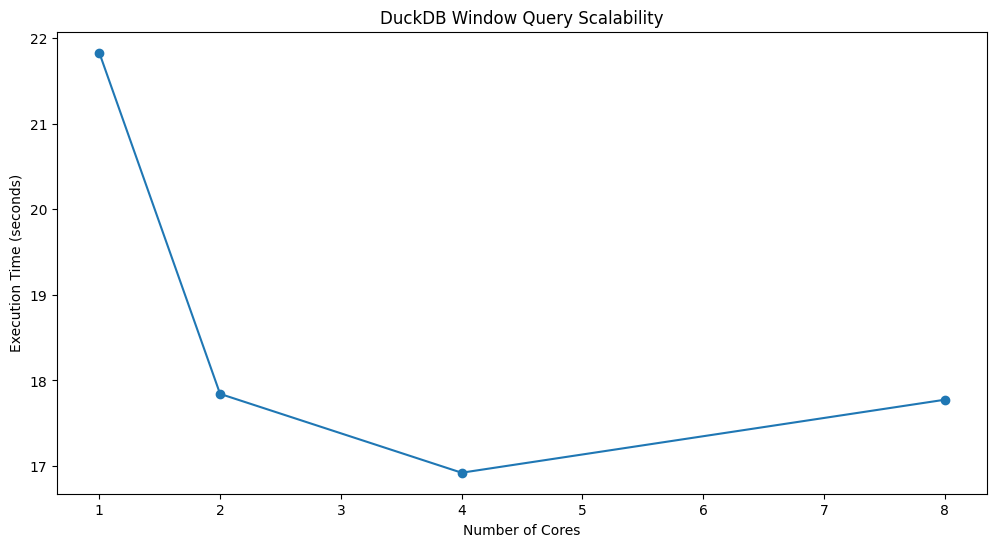

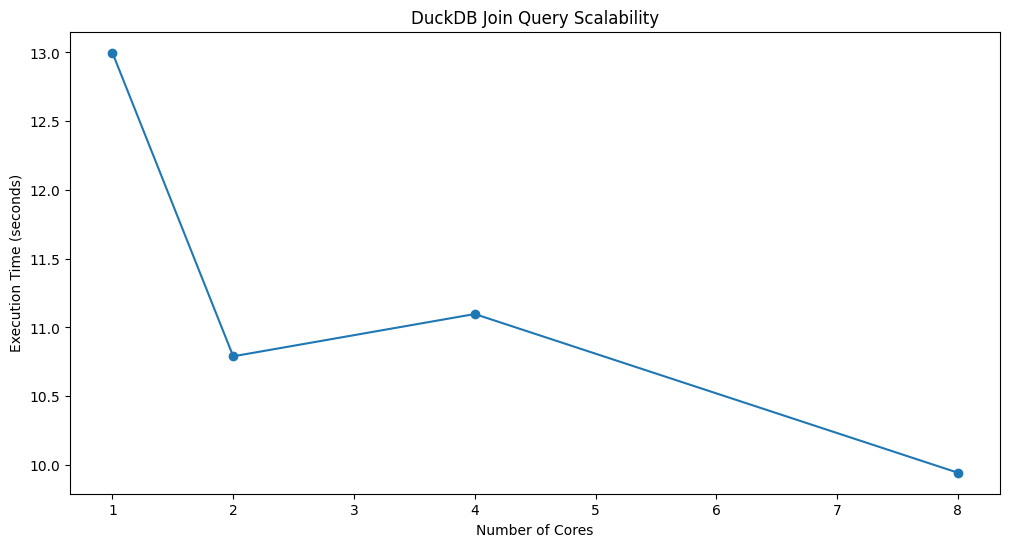

In [10]:
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_agregation,
    title='DuckDB Aggregation Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_window,
    title='DuckDB Window Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_join,
    title='DuckDB Join Query Scalability'
)


Spark

In [ ]:

times_per_core_agregation = utils.scalability_spark(TABLE_LOCATION, utils.AGGREGATION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for Spark for agregation query:")
for cores, t in times_per_core_agregation.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_window = utils.scalability_spark(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for Spark for window function query:")
for cores, t in times_per_core_window.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_join= utils.scalability_spark(TABLE_LOCATION, utils.JOIN_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for Spark for join query:")
for cores, t in times_per_core_join.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")


Times per core for DuckDB for agregation query:
Cores:  1, Time: 4.9190 seconds
Cores:  2, Time: 6.8961 seconds
Cores:  4, Time: 5.7229 seconds
Cores:  8, Time: 4.7366 seconds


Times per core for DuckDB for window function query:
Cores:  1, Time: 93.5754 seconds
Cores:  2, Time: 103.9766 seconds
Cores:  4, Time: 85.6147 seconds
Cores:  8, Time: 81.0984 seconds


Times per core for DuckDB for join query:
Cores:  1, Time: 73.1596 seconds
Cores:  2, Time: 74.0585 seconds
Cores:  4, Time: 62.7616 seconds
Cores:  8, Time: 63.1478 seconds


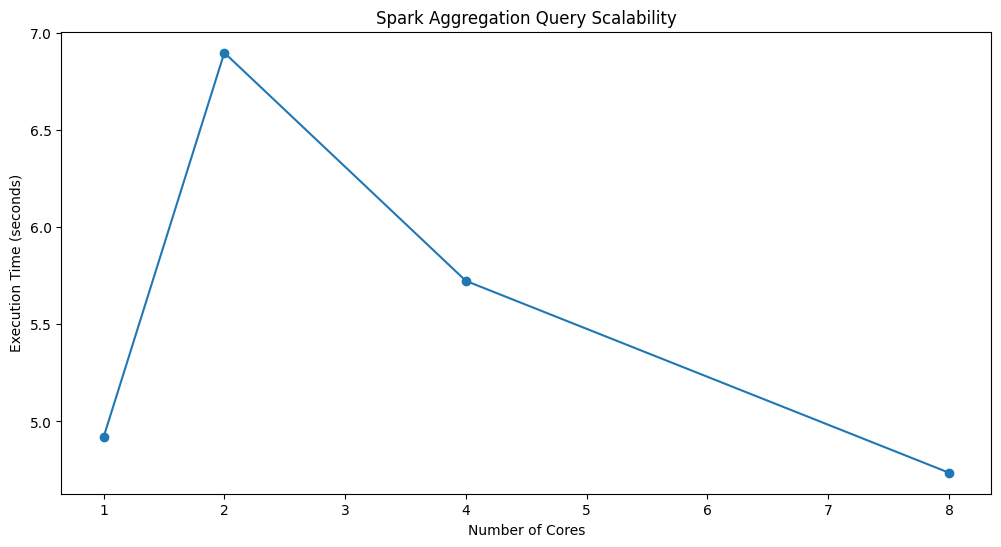

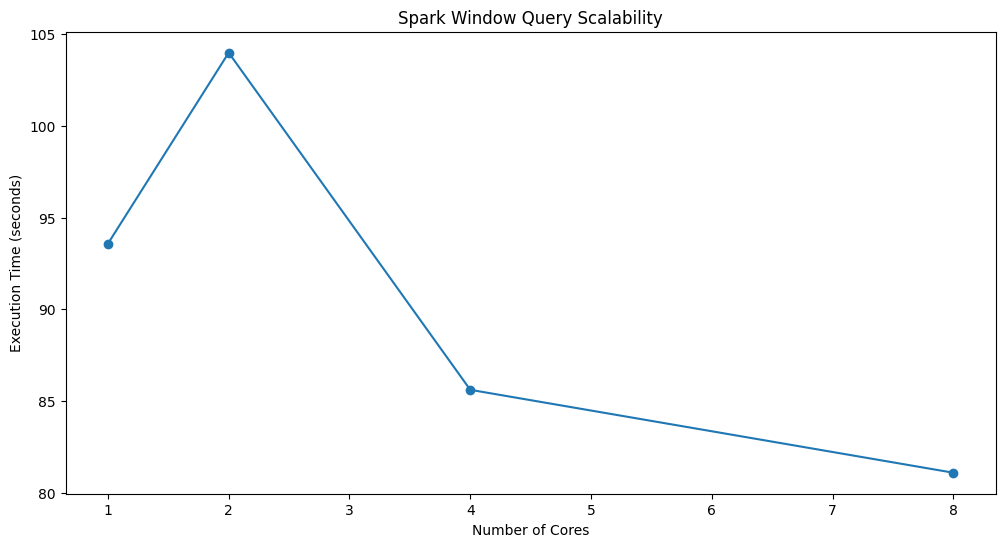

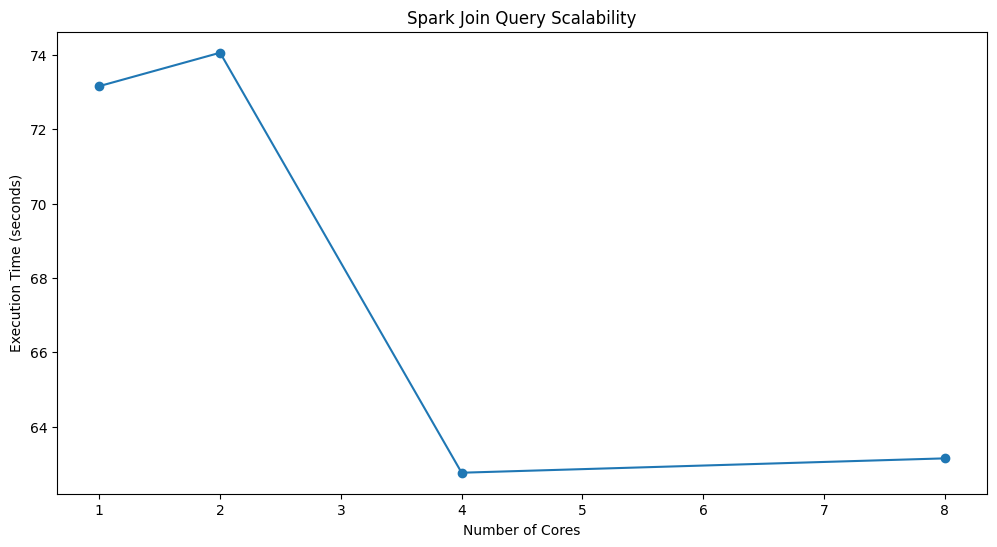

In [12]:
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_agregation,
    title='Spark Aggregation Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_window,
    title='Spark Window Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_join,
    title='Spark Join Query Scalability'
)

### Task 2: Spark on Cluster

**Goal**: Compare Single Node performance vs. Spark on a Cluster.

**Instructions**:
1.  **Infrastructure**: Use the infrastructure from **Phase 1** (Google Dataproc). You may need to modify your Terraform code to adjust the cluster configuration (e.g., number of worker nodes).
2.  **Environment**: The easiest way to run this is via **Google Workbench** connected to your Dataproc cluster.
3.  **Upload Data**: Upload the generated `social_media_data.parquet` to HDFS or GCS.
    -   **Tip**: For better performance, consider **partitioning** the data (e.g., by `category` or `date`) when saving it to the distributed storage. This allows Spark to optimize reads.
4.  **Run Queries**: Run your PySpark queries from Task 1 on the cluster.
5.  **Scalability Test**: 
    -   Run the queries with different numbers of **worker nodes** (e.g., 2, 3, 4).
    -   You can achieve this by resizing the cluster (manually or via Terraform) or by configuring the number of executors in Spark.
6.  **Analyze**:
    -   How does the cluster performance compare to your local machine?
    -   Did adding more nodes/executors linearly improve performance?
    -   **Tip**: If Spark is slower than single-node engines, consider **increasing the dataset size** (e.g., generate 10M+ records or duplicate the data). Spark's overhead is significant for small data, and its true power appears when data exceeds single-node memory.

In [13]:
# Your Code Here for Task 2

### Task 3: Execution Modes & Analysis

**Goal**: Deep dive into execution models and limitations.

**Instructions**:
1.  **Lazy vs. Eager vs. Streaming**:
    -   Use **Polars**. Compare the **Execution Time** and **Peak Memory** of:
        -   Eager execution (`read_parquet` -> filter).
        -   Lazy execution (`scan_parquet` -> filter -> `collect()`).
        -   Streaming execution (`scan_parquet` -> filter -> `collect(streaming=True)`).
2.  **Polars Limitations**:
    -   Identify a scenario where Polars might struggle compared to Spark (e.g., memory limits).
3.  **Decision Boundary**:
    -   Based on your findings, when would you recommend switching from a single-node tool (Polars/DuckDB) to a distributed engine (Spark)?

In [14]:
# Your Code Here for Task 3